# Интеллектуальный анализ данных – весна 2026
# Домашнее задание 6: классификация текстов

Правила:



*   Домашнее задание оценивается в 10 баллов.
*   Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.
*  Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.
*  Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.
*  Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.
* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

В этом домашнем задании вам предстоит построить классификатор текстов.

Будем предсказывать эмоциональную окраску твиттов о коронавирусе.



In [299]:
import numpy as np
import pandas as pd
from typing import  List
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation

In [300]:
df = pd.read_csv('/content/tweets_coronavirus.csv', encoding='latin-1')
df.sample(4)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
30198,40897,85849,"South West, England",10-04-2020,@CornwallLive I was in my local supermarket ye...,Extremely Negative
24635,33943,78895,"St.Petersburg, FL",06-04-2020,It will be interesting to watch lumber prices ...,Negative
5877,10936,55888,USA,19-03-2020,@David_desJ Right. The good or service. Not th...,Positive
18049,25761,70713,"Washington, DC",25-03-2020,"In Indiana, family-owned Indiana Safety and Su...",Extremely Positive


Для каждого твитта указано:


*   UserName - имя пользователя, заменено на целое число для анонимности
*   ScreenName - отображающееся имя пользователя, заменено на целое число для анонимности
*   Location - местоположение
*   TweetAt - дата создания твитта
*   OriginalTweet - текст твитта
*   Sentiment - эмоциональная окраска твитта (целевая переменная)



## Задание 1 Подготовка (0.5 балла)

Целевая переменная находится в колонке `Sentiment`.  Преобразуйте ее таким образом, чтобы она стала бинарной: 1 - если у твитта положительная или очень положительная эмоциональная окраска и 0 - если отрицательная или очень отрицательная.

In [301]:
df['Sentiment'].unique()

array(['Positive', 'Extremely Negative', 'Negative', 'Extremely Positive'],
      dtype=object)

In [302]:
# -- YOUR CODE HERE --
df['Sentiment']=np.where((df['Sentiment']=='Positive')|(df['Sentiment']=='Extremely Positive'), 1, 0)

In [303]:
df

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,1
1,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,1
2,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,1
3,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",0
4,3804,48756,"ÃÂT: 36.319708,-82.363649",16-03-2020,As news of the regionÃÂs first confirmed COV...,1
...,...,...,...,...,...,...
33439,44949,89901,OHIO,14-04-2020,I never that weÃÂd be in a situation &amp; w...,1
33440,44950,89902,NaN,14-04-2020,@MrSilverScott you are definitely my man. I fe...,1
33441,44952,89904,NaN,14-04-2020,Response to complaint not provided citing COVI...,0
33442,44953,89905,NaN,14-04-2020,You know itÃÂs getting tough when @KameronWi...,1


Сбалансированы ли классы?

In [304]:
# -- YOUR CODE HERE --
df['Sentiment'].value_counts()

,count
Sentiment,
1,18046
0,15398


**Ответ:** будем считать, что да (разница очень маленькая)

Выведете на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их строкой 'Unknown'.

In [305]:
# -- YOUR CODE HERE --
df.isna().sum()

,0
UserName,0
ScreenName,0
Location,7049
TweetAt,0
OriginalTweet,0
Sentiment,0


In [306]:
df = df.fillna('Unknown')

Разделите данные на обучающие и тестовые в соотношении 7 : 3 и укажите `random_state=0`

In [307]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.3, random_state=0)

## Задание 2 Токенизация (3 балла)

Постройте словарь на основе обучающей выборки и посчитайте количество встреч каждого токена с использованием самой простой токенизации - деления текстов по пробельным символам и приведения токенов в нижний регистр.

In [308]:
# -- YOUR CODE HERE --
from collections import Counter
text = ' '.join(train['OriginalTweet'])
counted = Counter(text.lower().split())
word_freq = pd.DataFrame(counted.items(), columns=['word', 'frequency']).sort_values(by='frequency', ascending=False)

Какой размер словаря получился?

In [309]:
# -- YOUR CODE HERE --
word_freq.shape

(79755, 2)

Выведите 10 самых популярных токенов с количеством встреч каждого из них. Объясните, почему именно эти токены в топе.

In [310]:
# -- YOUR CODE HERE --
word_freq.head(10)

,word,frequency
54,the,26815
4,to,23373
29,and,14684
129,of,13012
20,a,11737
141,in,11198
204,for,8566
69,#coronavirus,8223
23,is,7383
89,are,7050


**Ответ:** слова чаще всего являются просто предлогами ну или глаголами, которые не передают смысл, мы не можем говорить о том какие "несущие смысл" слова популярно, ну кроме #coronavirus, конечно. Его популярность легко объяснить, ведь это тематика датасета

Удалите стоп-слова из словаря и выведите новый топ-10 токенов (и количество встреч) по популярности.  Что можно сказать  о нем?

In [311]:
import nltk
from nltk.corpus import stopwords

# -- YOUR CODE HERE --
nltk.download('stopwords')
stop_words = stopwords.words('english')
l = word_freq[word_freq['word'].isin(stop_words)].index
word_freq1 = word_freq.drop(l)
word_freq1.head(10)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,word,frequency
69,#coronavirus,8223
432,prices,3891
99,food,3820
85,grocery,3469
202,supermarket,3288
91,people,3175
144,covid-19,3173
183,store,3155
198,#covid19,2471
636,&amp;,2314


**Ответ:** теперь мы можем судить о темах, которые чаще всего обсуждаются, теперь мы видим, что помимо короновируса еще одной популярной темой являются магазины, учитывая что второе по популярности слово это цены, скорее всего имеет место обсуждение рост цен в них, а также их специфическая работа в короновирус (вход в маске, приоритетнее заказать доставку и тд).

Также выведите 20 самых непопулярных слов (если самых непопулярных слов больше, выведите любые 20 из них) Почему эти токены непопулярны, требуется ли как-то дополнительно работать с ними?

In [312]:
# -- YOUR CODE HERE --
word_freq1.tail(20)

,word,frequency
79710,https://t.co/mrx9h61ffj,1
79709,"idiot,",1
79708,years'-supplies,1
79707,https://t.co/8ts1ja4aac,1
79748,renewing,1
79747,playersãâ,1
79746,subsidise,1
79745,non-playing,1
79744,premiership,1
79727,https://t.co/wojgzo5bsz,1


**Ответ:** видно, что часто это обращения к другим пользователям или ссылка на другие твиты и нам это мало что дает, не информативно, также в непопулряное попадают опечатки в результате, которых слово не попадает в свою "настоящую категорию". Нам бы хотелось избавиться от мусорных токенов, то есть вот от ссылок на пользователей, они вообще не нужны. А слова с опечатками мы бы хотели считать как правльные и засчитывать их в нужную категорию



Теперь воспользуемся токенайзером получше - TweetTokenizer из библиотеки nltk. Примените его и посмотрите на топ-10 популярных слов. Чем он отличается от топа, который получался раньше? Почему?

In [313]:
from nltk.tokenize import TweetTokenizer

# -- YOUR CODE HERE --

tw = TweetTokenizer()
counted = Counter(tw.tokenize(text))
word_freq_tw = pd.DataFrame(counted.items(), columns=['word', 'frequency']).sort_values(by='frequency', ascending=False)
word_freq_tw.head(10)

,word,frequency
67,the,24337
57,.,24108
4,to,22933
97,",",17571
29,and,14354
144,of,12904
20,a,11045
156,in,10573
106,?,9524
225,for,8228


**Ответ:** Они отличаютс от предыдущих, потому что теперь знаки припенания считываюся как особые символы, но пока мы не очистили суть все также понять по самым популярным невозможно

Удалите из словаря стоп-слова и пунктуацию, посмотрите на новый топ-10 слов с количеством встреч, есть ли теперь в нем что-то не похожее на слова?

In [314]:
from string import punctuation

# -- YOUR CODE HERE --
l = word_freq_tw[word_freq_tw['word'].isin(stop_words)].index
w = word_freq_tw.drop(l)
s = w[w['word'].isin(list(punctuation))].index
word_freq_tw_1 = w.drop(s)

word_freq_tw_1.head(10)

,word,frequency
74,Â,7415
73,,7311
161,19,7167
78,#coronavirus,7143
45,I,5235
75,,4372
452,prices,4281
159,COVID,4218
112,food,3795
95,store,3691


**Ответ:** да осталось достаточно много символов, они помечаны как нечитаемые, вероятнее всего это смайлики, а также видим букву А с крышечкой тоже не понятно, что под собой скрывает этот символ. также у нас теперь есть цифра 19, скорее всего она появилась после отделения от ковид-19

Скорее всего в некоторых топах были неотображаемые символы или отдельные буквы не латинского алфавита. Уберем их: удалите из словаря токены из одного символа, позиция которого в таблице Unicode 128 и более (`ord(x) >= 128`)

Выведите топ-10 самых популярных и топ-20 непопулярных слов. Чем полученные топы отличаются от итоговых топов, полученных при использовании токенизации по пробелам? Что теперь лучше, а что хуже?

In [315]:
# -- YOUR CODE HERE --
l2 = word_freq_tw_1[word_freq_tw_1['word'].apply(lambda x: len(x) == 1 and ord(x) >= 128)].index
word_freq_tw_2 = word_freq_tw_1.drop(l2)
word_freq_tw_2.head(10)

,word,frequency
161,19,7167
78,#coronavirus,7143
45,I,5235
452,prices,4281
159,COVID,4218
112,food,3795
95,store,3691
223,supermarket,3373
94,grocery,3083
101,people,3047


In [316]:
word_freq_tw_2.tail(20)

,word,frequency
68199,Vapers,1
68198,@DrAlexaMieses,1
68197,nicotine,1
68196,THC,1
22117,eleven,1
22115,promoters,1
22112,CONTINUE,1
68223,renewing,1
68222,playersÃ,1
68221,subsidise,1


**Ответ:** топ 10 отличается, но не сильно, в топе лучших появились новые слова такие как I веротяно много написаний в формате I'm и тд, которые пробельное раделение не делит, также топ-1 теперь стала цифра 19, но посыл у нее тоже по теме короновируса, так что мысли, волнующие людей не отличились. Касаемо топ-20 худших там все также очень много упомнинай других пользователей и ссылок на другие аккаунты, но теперь у нас нет слов, после которых стоит запятая просто и поэтому они не считываются к своей настоящей категории. в целом, твит-токанейзер лучше просто разделения по пробелам, потому что избавляет нас от изменения токенов из-за знаков препинания и тд

Выведите топ-10 популярных хештегов (токены, первые символы которых - #) с количеством встреч. Что можно сказать о них?

In [317]:
# -- YOUR CODE HERE --
word_freq_tw_2[word_freq_tw_2['word'].str.startswith('#')].head(10)


,word,frequency
78,#coronavirus,7143
218,#COVID19,1844
13,#Covid_19,1463
219,#Coronavirus,1281
926,#COVID2019,927
148,#toiletpaper,657
1420,#covid19,568
1068,#COVID,542
194,#CoronaCrisis,426
2659,#CoronaVirus,351


**Ответ:** все хештеги посвещаны основной теме твитов, они все (кроме шуточной туалетной бумаги) просто напрямую говорят о теме сообщения, суть ясно, но по хештегу, очевидно, эмоцональную окраску то нам не определить

То же самое проделайте для ссылок на сайт https://t.co Сравнима ли популярность ссылок с популярностью хештегов? Будет ли информация о ссылке на конкретную страницу полезна?

In [318]:
# -- YOUR CODE HERE --
word_freq_tw_2[word_freq_tw_2['word'].str.startswith('https://t.co')].head(10)

,word,frequency
18863,https://t.co/oXA7SWtoNd,5
2598,https://t.co/gP3EusapL8,4
11937,https://t.co/zjNRx6dKKN,3
28042,https://t.co/G63RP042HO,3
26644,https://t.co/CATKegAyOY,3
10477,https://t.co/kuwIpF1KQW,3
10291,https://t.co/WrLHYzIzAA,3
36409,https://t.co/WuiEEfSNOj,3
30268,https://t.co/AZIqCdgrNn,3
13960,https://t.co/3GBBDpdjat,3


**Ответ:** мы видем, что не в целм какой-то суперпопоулярной ссылки, тогда бы мы могли говорить о том на что ссылаются пользователи, но так все ссылки стречаются максимум несколько раз и мы не можем сделать никак особенных выводов

Используем опыт предыдущих экспериментов и напишем собственный токенайзер, улучшив TweetTokenizer. Функция tokenize должна:



*   Привести текст в нижний регистр
*   Применить TweetTokenizer для  выделения токенов
*   Удалить стоп-слова, пунктуацию, токены из одного символа с позицией в таблице Unicode 128 и более,  ссылки на t.co



In [319]:
def custom_tokenizer(text):

  # -- YOUR CODE HERE --
  text = text.lower()
  tokens = tw.tokenize(text)
  tokens = [t for t in tokens if t not in stop_words and t not in punctuation and not (len(t) == 1 and ord(t) >= 128) and not t.startswith('https://t.co')]
  return tokens


In [320]:
custom_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext')

['sample', 'text', '@sample_text', '#sampletext']

## Задание 3 Векторизация текстов (2 балла)

Обучите CountVectorizer с использованием custom_tokenizer в качестве токенайзера. Как размер полученного словаря соотносится с размером изначального словаря из начала задания 2?

In [321]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(tokenizer=custom_tokenizer)
X = cv.fit_transform(train['OriginalTweet'])
print(len(cv.vocabulary_))

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


45290


**Ответ:** наш новый словарь значительно меньше по размеру с изначальным в задании 2, но при этом мы не потеряли ничего по смыслу

Посмотрим на какой-нибудь конкретный твитт:

In [322]:
ind = 9023
train.iloc[ind]['OriginalTweet'], train.iloc[ind]['Sentiment']

('Nice one @SkyNews lets not panic but show ppl in france queueing for food!!! #CoronavirusOutbreak #COVID2019 brainless!! Ffs',
 np.int64(0))

Автор твитта не доволен ситуацией с едой во Франции и текст имеет резко негативную окраску.

Примените обученный CountVectorizer для векторизации данного текста, и попытайтесь определить самый важный токен и самый неважный токен (токен, компонента которого в векторе максимальна/минимальна, без учета 0). Хорошо ли они определились, почему?

In [348]:
# -- YOUR CODE HERE --
vect = cv.transform([train.iloc[ind]['OriginalTweet']])
vect = vect.toarray()[0]
names = cv.get_feature_names_out()
res=[(names[i], int(vect[i])) for i in np.where(vect > 0)[0]]
res

[('#coronavirusoutbreak', 1),
 ('#covid2019', 1),
 ('@skynew', 1),
 ('brainless', 1),
 ('ffs', 1),
 ('food', 1),
 ('franc', 1),
 ('let', 1),
 ('nice', 1),
 ('one', 1),
 ('panic', 1),
 ('ppl', 1),
 ('queue', 1),
 ('show', 1)]

**Ответ:** видим, что все слова упоминаются с одинаковой частотой, поэтому мы не можем судить о том какое изних будет более выжным, из-за того что слов мало CountVectorizer не справлется, у нас получается, что все символы имеют равную важность

Теперь примените TfidfVectorizer и  определите самый важный/неважный токены. Хорошо ли определились, почему?

In [349]:
# -- YOUR CODE HERE --
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vec = TfidfVectorizer(tokenizer=custom_tokenizer)
X = tfidf_vec.fit_transform(train['OriginalTweet'])
vect = tfidf_vec.transform([train.iloc[ind]['OriginalTweet']])
vect = vect.toarray()[0]
names = tfidf_vec.get_feature_names_out()
res=[(names[i], vect[i]) for i in np.where(vect > 0)[0]]
print(sorted(res, key=lambda x: x[1])[0])
print(sorted(res, key=lambda x: x[1])[-1])

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


('food', np.float64(0.11328893069250721))
('brainless', np.float64(0.3867641170466375))


**Ответ:** TfidfVectorizer смог определить важный и неважный токен, дело в том что он считает не просто частоту упоминаний в конкретном твите, а делает поправку на все данные, поэтому важностью начинают обладать слова которые редко встречаются во всех данных (food очень популярно, поэтому получила наименьшую важность)

Найдите какой-нибудь положительно окрашенный твитт, где TfidfVectorizer хорошо (полезно для определения окраски) выделяет важный токен, поясните пример.

*Подсказка:* явно положительные твитты можно искать при помощи положительных слов (good, great, amazing и т. д.)

In [325]:
train[train['OriginalTweet'].apply(lambda x: 'wonderful' in x) & (train['Sentiment'] == 1)]

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
20160,28380,73332,London/Dorking,26-03-2020,"@caitlinmoran Brilliant, but how about showing...",1
5274,10212,55164,"London, England",19-03-2020,So grateful to @POTAGELONDON today. Not only w...,1
3747,8344,53296,VA,18-03-2020,Sad sign of the times: Just before the alarm w...,1
19432,27458,72410,ADHS 67 Algonquin Civil 70,26-03-2020,Please be aware and give everyone their space ...,1
31953,43102,88054,"Scotland, United Kingdom",12-04-2020,I understand and get the wonderful job the sup...,1
2587,6928,51880,UK,18-03-2020,Just what to say what a wonderful job @AldiUK ...,1
22910,31792,76744,United Kingdom,04-04-2020,amp are often most impacted by cirisis yet mos...,1
10014,15960,60912,Unknown,21-03-2020,With US grocery store shelves empty of TP Toil...,1
22786,31645,76597,"Madison, WI, US, 53719",03-04-2020,Stickley furniture is built to withstand gener...,1
14975,22007,66959,Unknown,23-03-2020,. I spoke to local business owners hillside Av...,1


In [350]:
# -- YOUR CODE HERE --
g=train[train['UserName']==15004]
vect = tfidf_vec.transform([g.iloc[0]['OriginalTweet']])
vect = vect.toarray()[0]
names = tfidf_vec.get_feature_names_out()
res=[(names[i], vect[i]) for i in np.where(vect > 0)[0]]
print(sorted(res, key=lambda x: x[1], reverse=True))


[('great', np.float64(0.33757866226515565)), ('atmosphere', np.float64(0.32555719584053466)), ('local', np.float64(0.29623644807969435)), ('france', np.float64(0.2697570233474981)), ('wonderful', np.float64(0.2681916024422372)), ('#convid19uk', np.float64(0.2652636277484166)), ('friendly', np.float64(0.2525674953674938)), ('traders', np.float64(0.23615604785708463)), ('queues', np.float64(0.23332661051351336)), ('street', np.float64(0.2204140755793006)), ('yesterday', np.float64(0.20206156425741548)), ('produce', np.float64(0.20142462761916655)), ('went', np.float64(0.17285261045524503)), ('empty', np.float64(0.16452597389835819)), ('customers', np.float64(0.16195701954843678)), ('market', np.float64(0.16182709474971751)), ('shelves', np.float64(0.14510766262533303)), ('like', np.float64(0.12542492930158058)), ('shopping', np.float64(0.12025967136300637)), ('prices', np.float64(0.09047142721350018)), ('#coronavirus', np.float64(0.06672540240694497))]


**Ответ:** изначально я искала пример со словом wonderful, конечно оно тоже есть в этом твите и он 5 по важности, но примечательно, что топ1 другое положительно окрашенное слово great, получается, что оно важнее, чем wonderful, но суть остается той же, наибольшую важность имеют действительно значимые для нас слова, которые описывают эмоцию и по ним легко определить, что твит будет относиться к положительно окрашенному

 ## Задание 4 Обучение первых моделей (1 балл)

Примените оба векторайзера для получения матриц с признаками текстов.  Выделите целевую переменную.

In [327]:
# -- YOUR CODE HERE --
X_train_cv = cv.fit_transform(train['OriginalTweet'])
X_test_cv = cv.transform(test['OriginalTweet'])

X_train_tfidf = tfidf_vec.fit_transform(train['OriginalTweet'])
X_test_tfidf = tfidf_vec.transform(test['OriginalTweet'])

y_train = train['Sentiment']
y_test = test['Sentiment']

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Обучите логистическую регрессию на векторах из обоих векторайзеров. Посчитайте долю правильных ответов на обучающих и тестовых данных. Какой векторайзер показал лучший результат? Что можно сказать о моделях?

Используйте `sparse` матрицы (после векторизации), не превращайте их в `numpy.ndarray` или `pd.DataFrame` - может не хватить памяти.

In [328]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# -- YOUR CODE HERE --
model=LogisticRegression()

model.fit(X_train_cv, y_train)
train_pr = model.predict(X_train_cv)
test_pr = model.predict(X_test_cv)
print('Train', accuracy_score(y_train, train_pr))
print('Test', accuracy_score(y_test, test_pr))


Train 0.9846646732165741
Test 0.8670520231213873


In [329]:
model.fit(X_train_tfidf, y_train)
train_pr = model.predict(X_train_tfidf)
test_pr = model.predict(X_test_tfidf)
print('Train', accuracy_score(y_train, train_pr))
print('Test', accuracy_score(y_test, test_pr))

Train 0.9224263135412217
Test 0.85280047837353



**Ответ:** резултаты на тесте практически не отличаются, CountVectorizer незначительно лучше, а вот касательно результата на тренировочных данных у CountVectorizer резултат сильно лучше его теста, результат на тренирововчных очень выскоий, у TfidfVectorizer такого разрыва нет, мы можем гворить о том, что переобучение у CountVectorizer выше, но это тоже не аномальные значения, так что оба векторайзера работают примерно на равных, только CountVectorizer дает более точные результаты на тесте, но он же и сильнее подвержен переобучению

## Задание 5 Стемминг (0.5 балла)

Для уменьшения словаря можно использовать стемминг.

Модифицируйте написанный токенайзер, добавив в него стемминг с использованием SnowballStemmer. Обучите Count- и Tfidf- векторайзеры. Как изменился размер словаря?

In [330]:
from nltk.stem.snowball import SnowballStemmer
def custom_stem_tokenizer(text):
  # -- YOUR CODE HERE --
  stemmer = SnowballStemmer('english')
  text = text.lower()
  tokens = tw.tokenize(text)
  tokens = [t for t in tokens if t not in stop_words and t not in punctuation and not (len(t) == 1 and ord(t) >= 128) and not t.startswith('https://t.co')]
  tokens = [stemmer.stem(w) for w in tokens]
  return tokens

In [331]:
custom_stem_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext adding more words to check stemming')

['sampl', 'text', '@sample_text', '#sampletext', 'ad', 'word', 'check', 'stem']

In [332]:
 # -- YOUR CODE HERE --
cv = CountVectorizer(tokenizer=custom_stem_tokenizer)
X = cv.fit_transform(train['OriginalTweet'])
tfidf_vec = TfidfVectorizer(tokenizer=custom_stem_tokenizer)
X1 = tfidf_vec.fit_transform(train['OriginalTweet'])
print(len(cv.vocabulary_))

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


36634


**Ответ** Благодаря стеммингу удалось значитьельно уменьшить размер словаря, но при этом мы не выкинули никаких выжных элементов

Обучите логистическую регрессию с использованием обоих векторайзеров. Изменилось ли качество? Есть ли смысл применять стемминг?

In [333]:
# -- YOUR CODE HERE --
X_train_cv = cv.fit_transform(train['OriginalTweet'])
X_test_cv = cv.transform(test['OriginalTweet'])
X_train_tfidf = tfidf_vec.fit_transform(train['OriginalTweet'])
X_test_tfidf = tfidf_vec.transform(test['OriginalTweet'])
model=LogisticRegression()

model.fit(X_train_cv, y_train)
train_pr = model.predict(X_train_cv)
test_pr = model.predict(X_test_cv)
print('Train', accuracy_score(y_train, train_pr))
print('Test', accuracy_score(y_test, test_pr))

Train 0.9720205040580948
Test 0.8674506677297189


In [334]:
model.fit(X_train_tfidf, y_train)
train_pr = model.predict(X_train_tfidf)
test_pr = model.predict(X_test_tfidf)
print('Train', accuracy_score(y_train, train_pr))
print('Test', accuracy_score(y_test, test_pr))

Train 0.9165741136266553
Test 0.8559896352401833


**Ответ:** результаты рактически не измненились, так что использовать стемминг есть смысл, когда нам важен размер словаря, но для результатов на трейне и тесте это не дает сильных изменений

## Задание  6 Работа с частотами (1.5 балла)

Еще один способ уменьшить количество признаков - это использовать параметры min_df и max_df при построении векторайзера  эти параметры помогают ограничить требуемую частоту встречаемости токена в документах.

По умолчанию берутся все токены, которые встретились хотя бы один раз.



Подберите max_df такой, что размер словаря будет 36651 (на 1 меньше, чем было). Почему параметр получился такой большой/маленький?

In [335]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        max_df=0.3 # -- YOUR CODE HERE --
                        ).fit(
                            train['OriginalTweet']# -- YOUR CODE HERE --
                            )
print(len(cv_df.vocabulary_))

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


36633


**Ответ:** изначальный размер словаря получился немного другой (судя по сообщениям в чате это ок), был подобран max_df, который аналиогично уменьшает размер на 1. Параметр получился достаточно маленький, сам параметр говорит о том, что мы удаляем слова, которые встречаюся в практически 1/3 твитов, до этого значения словаря не уменьшался, то есть у нас нет слишком часто встречающихся слов в твитах

Подберите min_df (используйте дефолтное значение max_df) в CountVectorizer таким образом, чтобы размер словаря был 3700 токенов (при использовании токенайзера со стеммингом), а качество осталось таким же, как и было. Что можно сказать о результатах?

In [336]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        min_df=11# -- YOUR CODE HERE --
                        ).fit(train['OriginalTweet']
                            # -- YOUR CODE HERE --
                            )
print(len(cv_df.vocabulary_))

3687


In [337]:
# -- YOUR CODE HERE --

X_train_min = cv_df.transform(train['OriginalTweet'])
X_test_min = cv_df.transform(test['OriginalTweet'])
model = LogisticRegression()
model.fit(X_train_min, y_train)
train_pred = model.predict(X_train_min)
test_pred = model.predict(X_test_min)
print('Train', accuracy_score(y_train, train_pred))
print('Test', accuracy_score(y_test, test_pred))

Train 0.9290046988466467
Test 0.8680486346422165


**Ответ:** опять же из-за разницы с начальным датасетом точно такая же цифра невозможно, но наиболее адекатным получается ответ при параметре min_df=11, перебираем по абсолютной шкале, вместо относительной, потому что так удобнее, слишком маленькие значения для относительной шкалы. При этом показателе мы достигаем нужного (предположительно из погрешности) размера словаря и при это не теряем качество на тесте (даже незначительно улучшаем), а вот на трейне качество падает, что как раз тоже хорошо, ведь мы уменьшаем переобучение. Мы удаляем слова, которые встречаются меньше 11 раз, поэтому модель перестает подстраивать свои предсказания под редкие случаи и мы уменьшаем переобучение

В предыдущих заданиях признаки не скалировались. Отскалируйте данные (при словаре размера 3.7 тысяч, векторизованные CountVectorizer), обучите логистическую регрессию, посмотрите качество и выведите `barplot`, содержащий по 10 токенов, с наибольшим по модулю положительными/отрицательными весами. Что можно сказать об этих токенах?

In [338]:
from sklearn.preprocessing import StandardScaler
# -- YOUR CODE HERE --
X_train_min = cv_df.transform(train['OriginalTweet'])
X_test_min = cv_df.transform(test['OriginalTweet'])
normalizer = StandardScaler(with_mean=False)
X_train_min = normalizer.fit_transform(X_train_min)
X_test_min = normalizer.transform(X_test_min)
model = LogisticRegression()
model.fit(X_train_min, y_train)
train_pred = model.predict(X_train_min)
test_pred = model.predict(X_test_min)
print('Train', accuracy_score(y_train, train_pred))
print('Test', accuracy_score(y_test, test_pred))

Train 0.9414780008543358
Test 0.8447279250548136


/tmp/ipykernel_6787/4231423140.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=all_t, x='weight', y='token', palette=np.where(all_t['weight'] < 0, 'red', 'blue'))
/tmp/ipykernel_6787/4231423140.py:9: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(data=all_t, x='weight', y='token', palette=np.where(all_t['weight'] < 0, 'red', 'blue'))


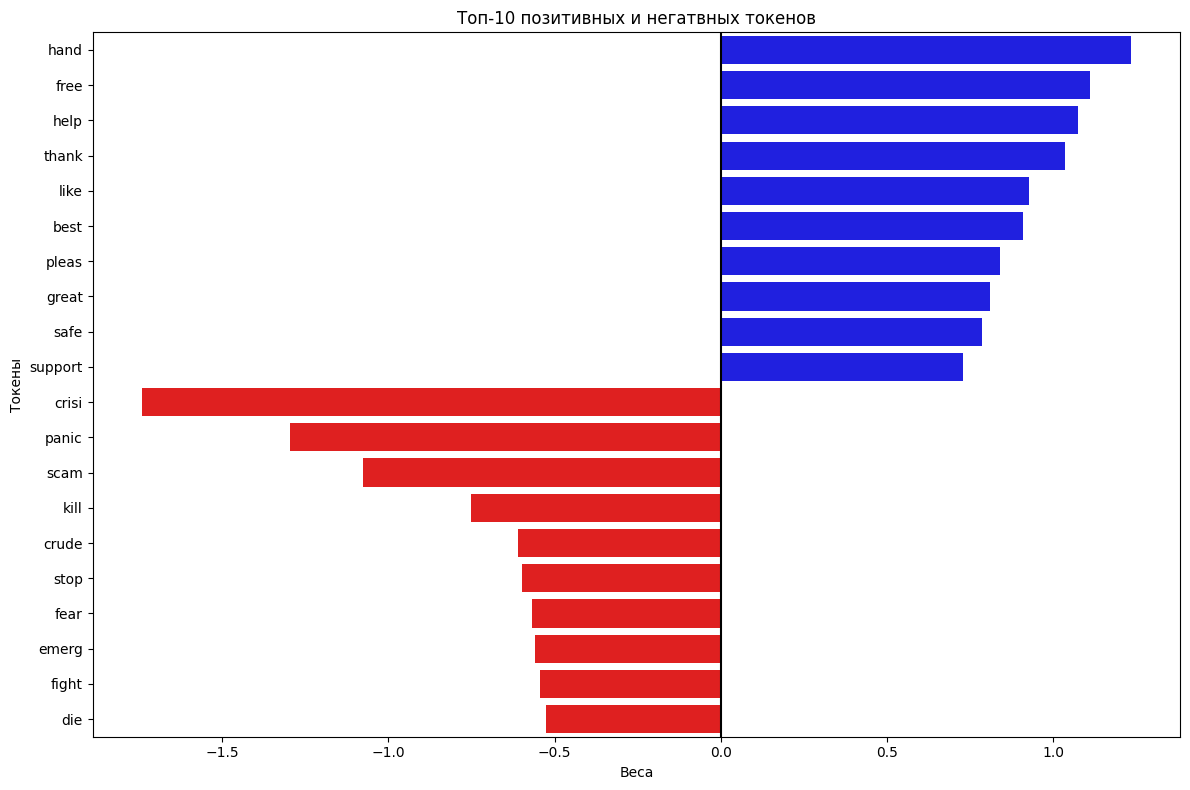

In [339]:
weight = model.coef_[0]
token = cv_df.get_feature_names_out()
d1 = pd.DataFrame({'token': token, 'weight': weight})
positive = d1.nlargest(10, 'weight')
negative = d1.nsmallest(10, 'weight')
all_t = pd.concat([positive, negative])

plt.figure(figsize=(12, 8))
sns.barplot(data=all_t, x='weight', y='token', palette=np.where(all_t['weight'] < 0, 'red', 'blue'))
plt.axvline(x=0, color='black')
plt.xlabel('Веса')
plt.ylabel('Токены')
plt.title('Топ-10 позитивных и негатвных токенов')
plt.tight_layout()
plt.show()


**Ответ:** для начала хотелось бы заметить, что теперь у нас все же немного упало качество на тестовой выборке и подросло на тренировочной, то есть мы немного, но увеличили переобучение. Касательно токенов, негативные показывают как раз верно слова с очевидно негатвиной окраской (кризис, паника, скам и тд), позитивные тоже достаточно верно классифицируются и мы видим много слов благодарности, но в целом еще заметно, что слова отличаются от тех, что мы получали ранее

## Задание 7 Другие признаки (1.5 балла)

Мы были сконцентрированы на работе с текстами твиттов и не использовали другие признаки - имена пользователя, дату и местоположение

Изучите признаки UserName и ScreenName. полезны ли они? Если полезны, то закодируйте их, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [340]:
# -- YOUR CODE HERE --
print(df['UserName'].value_counts().max() == 1)
print(df['ScreenName'].value_counts().max() == 1)

True
True


**Ответ:** признаки абсолютно бесполезны, об этом можно было догадать еще в самом начале, ведь в описании датасета сказано, что пользовательям присвоенные рандомно числа, в том, чтобы смотреть этот признак был бы смысл если бы у нас было несколько пользователей и они бы все были закодированы каждый в соотвествии себе, у нас как видно такого не происходит, так что это просто рандомный набор цифр, который никак не сделает модель лучше

Изучите признак TweetAt в обучающей выборке: преобразуйте его к типу datetime и нарисуйте его гистограмму с разделением по цвету на основе целевой переменной. Полезен ли он? Если полезен, то закодируйте его, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

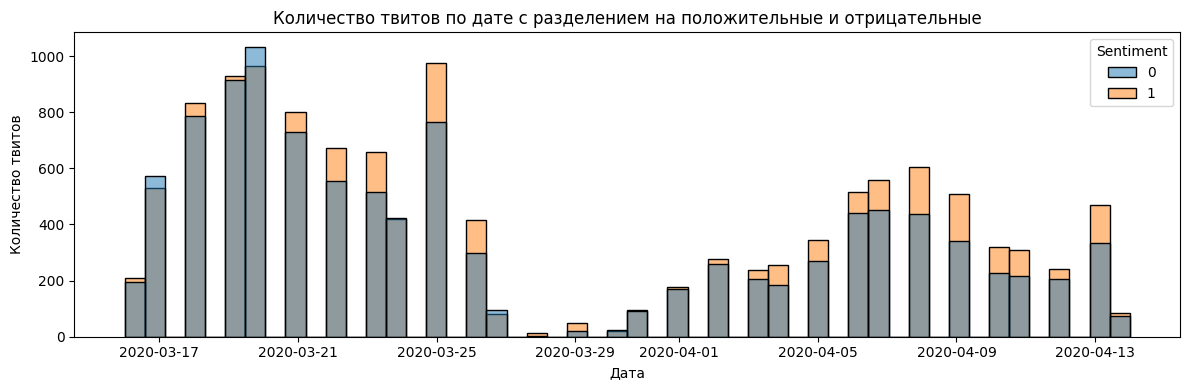

In [341]:
# -- YOUR CODE HERE --
train['TweetAt'] = pd.to_datetime(train['TweetAt'], format="%d-%m-%Y")
plt.figure(figsize=(12, 4))
sns.histplot(data=train, x='TweetAt', hue='Sentiment', multiple='layer', bins=50)
plt.title('Количество твитов по дате с разделением на положительные и отрицательные')
plt.xlabel('Дата')
plt.ylabel('Количество твитов')
plt.tight_layout()
plt.show()

**Ответ:** признак тоже бесполезен, видим что распределение на положительные и отрицательные в целом не зависит от времени, почти всегда немного преобладают положительные, есть пара с преобладанием отрицательных, но нигде нет колосального разрыва, признак не даст модели ничего из даты нельзя понять эмоциональную окраску твита, по сути из этого признака просто "угадайка практически 50 на 50"



Поработайте с признаком Location в обучающей выборке. Сколько уникальных значений?

In [342]:
# -- YOUR CODE HERE --
len(train['Location'].unique())

7949

Постройте гистограмму топ-10 по популярности местоположений (исключая Unknown)

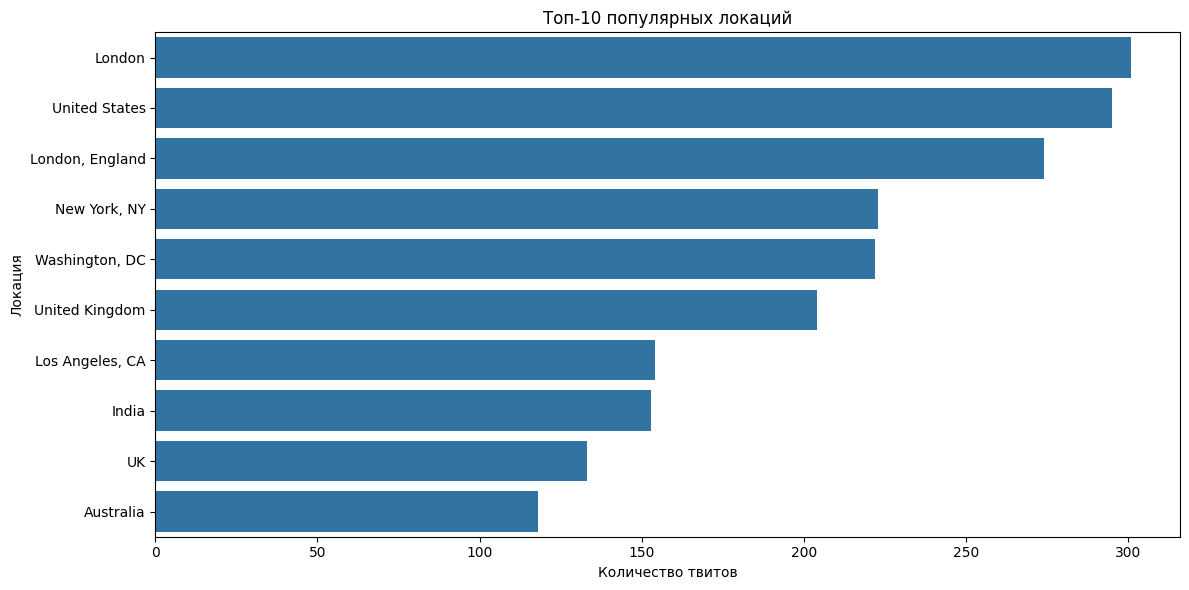

In [343]:
# -- YOUR CODE HERE --
s = train['Location'].value_counts().drop('Unknown')
res = s.head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=res.values, y=res.index)
plt.xlabel('Количество твитов')
plt.ylabel('Локация')
plt.title('Топ-10 популярных локаций')
plt.tight_layout()
plt.show()

Видно, что многие местоположения включают в себя более точное название места, чем другие (Например, у некоторых стоит London, UK; а у некоторых просто UK или United Kingdom).

Создайте новый признак WiderLocation, который содержит самое широкое местоположение (например, из London, UK должно получиться UK). Сколько уникальных категорий теперь? Постройте аналогичную гистограмму.

In [344]:
# -- YOUR CODE HERE --
def go_WiderLocation(x):
  if x!= 'Unknown':
    names=list(map(str.strip, x.split(',')))
    return names[-1]
  return 'Unknown'

train['WiderLocation'] = train['Location'].map(go_WiderLocation)
test['WiderLocation'] = test['Location'].map(go_WiderLocation)
print(len(train['WiderLocation'].unique()))

4631


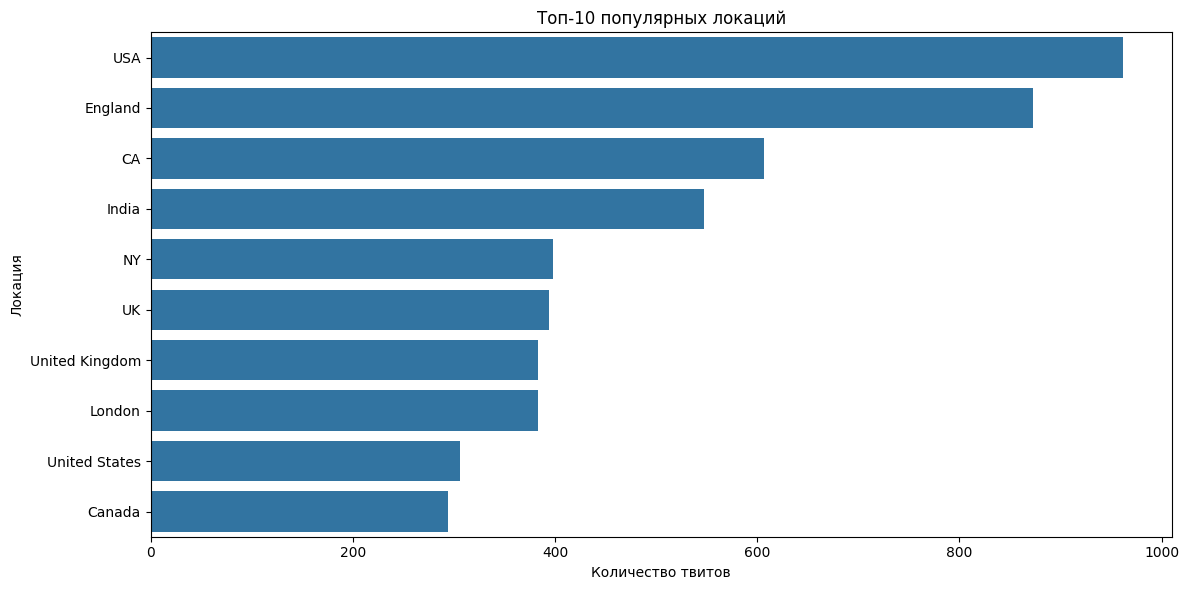

In [345]:
s = train['WiderLocation'].value_counts().drop('Unknown')
res = s.head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=res.values, y=res.index)
plt.xlabel('Количество твитов')
plt.ylabel('Локация')
plt.title('Топ-10 популярных локаций')
plt.tight_layout()
plt.show()

Закодируйте признак WiderLocation с помощью OHE таким образом, чтобы создались только столбцы для местоположений, которые встречаются более одного раза. Сколько таких значений?


In [346]:
from sklearn.preprocessing import OneHotEncoder
s = train['WiderLocation'].value_counts()
res = s[s>1].index.tolist()
print(len(res))

method = OneHotEncoder(categories=[res], handle_unknown='ignore', sparse_output=True)
train7 = method.fit_transform(train[['WiderLocation']])
test7 = method.transform(test[['WiderLocation']])


988


Добавьте этот признак к матрице отскалированных текстовых признаков, обучите логистическую регрессию, замерьте качество. Как оно изменилось? Оказался ли признак полезным?


*Подсказка:* используйте параметр `categories` в энкодере.

In [351]:
# -- YOUR CODE HERE --
import scipy.sparse as sp
train_res = sp.hstack([X_train_min, train7])
test_res = sp.hstack([X_test_min, test7])
model = LogisticRegression()
model.fit(train_res, y_train)
train_pred = model.predict(train_res)
test_pred = model.predict(test_res)
print('Train', accuracy_score(y_train, train_pred))
print('Test', accuracy_score(y_test, test_pred))

Train 0.9449807774455361
Test 0.8444289415985649


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Ответ:** (было Train 0.9414780008543358
Test 0.8447279250548136) чуть-чуть выросло качество на трейне, при этом на тесте подупало, но маштабы конечно очень малы, так что, скорее признак не является полезным, но еще стоит учесть, что с помощью WiderLocation мы все таки не очень хорошо разделили регионы, но даже при идеальной ситуации вряд ли признак будет полезен, главную ценность все равно несет текст твита, остальные признаки оказываются несущественными